In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
fund = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/processed/clean_nav.csv")

performance = pd.read_csv("../data/processed/clean_performance.csv")

transactions = pd.read_csv(
    "../data/processed/clean_transactions.csv"
)

portfolio = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

In [3]:
print(fund.shape)
print(nav.shape)
print(performance.shape)
print(transactions.shape)
print(portfolio.shape)

(40, 15)
(46000, 3)
(40, 20)
(32778, 13)
(322, 8)


In [4]:
print(fund.columns.tolist())
print(nav.columns.tolist())
print(performance.columns.tolist())
print(transactions.columns.tolist())
print(portfolio.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']
['amfi_code', 'date', 'nav']
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'negative_sharpe']
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [5]:
nav["date"] = pd.to_datetime(nav["date"])

In [6]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

In [7]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [8]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [9]:
var_results = []

for fund_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) == 0:
        continue

    var_95 = np.percentile(returns, 5)

    cvar_95 = returns[
        returns <= var_95
    ].mean()

    var_results.append({
        "amfi_code": fund_code,
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })

var_cvar = pd.DataFrame(var_results)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [10]:
var_cvar["VaR_95_pct"] = (
    var_cvar["VaR_95"] * 100
)

var_cvar["CVaR_95_pct"] = (
    var_cvar["CVaR_95"] * 100
)

In [11]:
var_cvar = var_cvar.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [12]:
var_cvar = var_cvar[
    [
        "amfi_code",
        "scheme_name",
        "VaR_95_pct",
        "CVaR_95_pct"
    ]
]

In [14]:
var_cvar.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

In [15]:
fund[
    ["amfi_code", "scheme_name"]
].head(10)

,amfi_code,scheme_name
0,119551,SBI Bluechip Fund - Regular Plan - Growth
1,119552,SBI Bluechip Fund - Direct Plan - Growth
2,119598,SBI Small Cap Fund - Regular Plan - Growth
3,119599,SBI Small Cap Fund - Direct Plan - Growth
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth
5,100016,HDFC Top 100 Fund - Regular Plan - Growth
6,125497,HDFC Top 100 Fund - Direct Plan - Growth
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth
9,100025,HDFC Short Term Debt Fund - Regular - Growth


In [16]:
selected_funds = (
    fund["amfi_code"]
    .dropna()
    .unique()[:5]
)

selected_funds

array([119551, 119552, 119598, 119599, 119120])

In [17]:
rolling_data = nav[
    nav["amfi_code"].isin(selected_funds)
].copy()

In [18]:
rolling_data["rolling_sharpe"] = (
    rolling_data
    .groupby("amfi_code")["daily_return"]
    .transform(
        lambda x:
        x.rolling(90).mean()
        /
        x.rolling(90).std()
        *
        np.sqrt(252)
    )
)

In [19]:
rolling_data = rolling_data.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

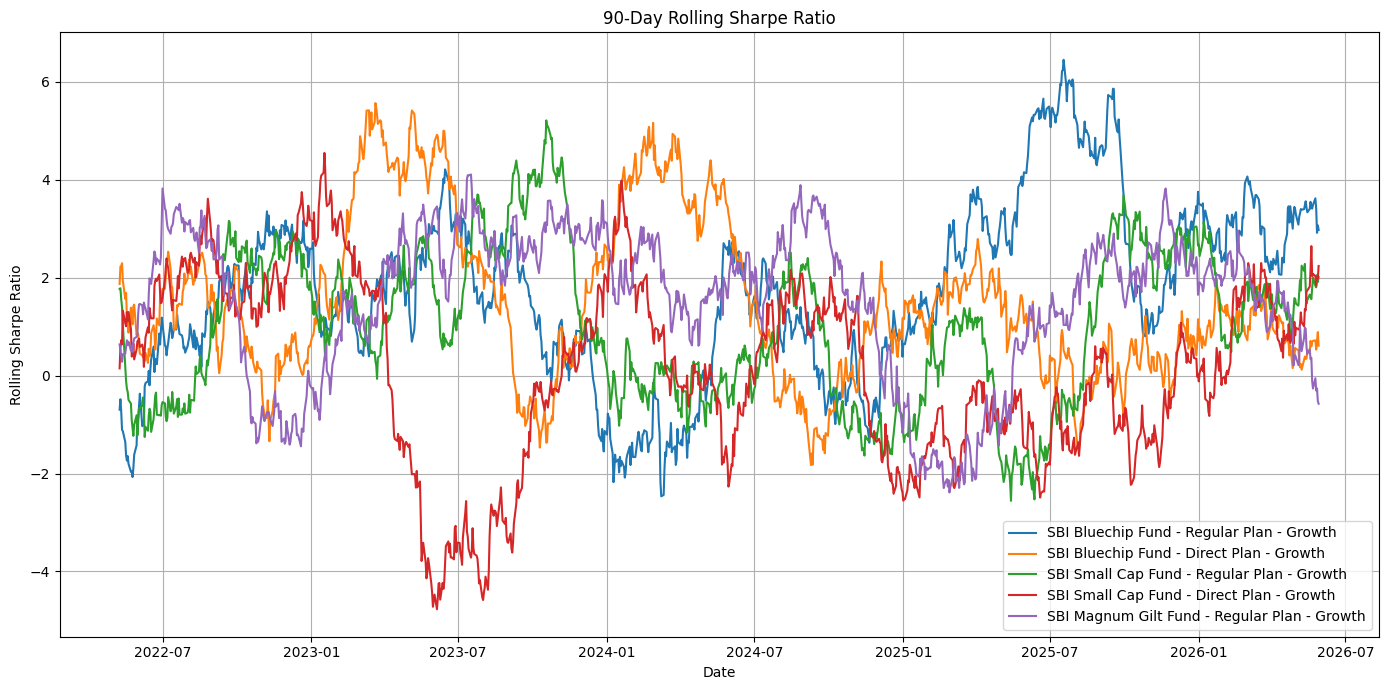

In [21]:
plt.figure(figsize=(14, 7))

for code in selected_funds:

    temp = rolling_data[
        rolling_data["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=temp["scheme_name"].iloc[0]
    )

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/charts/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

In [22]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [23]:
first_transaction = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

In [24]:
first_transaction.columns = [
    "investor_id",
    "first_transaction_date"
]

In [25]:
first_transaction["cohort_year"] = (
    first_transaction["first_transaction_date"]
    .dt.year
)

In [26]:
first_transaction = first_transaction[
    first_transaction["cohort_year"].isin(
        [2024, 2025]
    )
]

In [27]:
cohort_data = transactions.merge(
    first_transaction[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="inner"
)

In [28]:
sip_data = cohort_data[
    cohort_data["transaction_type"].str.lower() == "sip"
]

In [29]:
avg_sip = (
    sip_data
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="average_sip_amount")
)

In [30]:
total_invested = (
    cohort_data
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested")
)

In [31]:
preference = (
    cohort_data
    .groupby("cohort_year")["transaction_type"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index(name="preferred_transaction_type")
)

In [32]:
cohort_analysis = (
    avg_sip
    .merge(
        total_invested,
        on="cohort_year"
    )
    .merge(
        preference,
        on="cohort_year"
    )
)

In [33]:
cohort_analysis

,cohort_year,average_sip_amount,total_invested,preferred_transaction_type
0,2024,10996.885825,3491125187,Sip
1,2025,13505.209581,30455243,Sip


In [34]:
cohort_analysis.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

In [35]:
sip = transactions[
    transactions["transaction_type"].str.lower() == "sip"
].copy()

In [36]:
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

In [37]:
sip["days_since_previous_sip"] = (
    sip
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

In [38]:
sip_continuity = (
    sip
    .groupby("investor_id")
    .agg(
        sip_transaction_count=(
            "transaction_date",
            "count"
        ),
        average_gap_days=(
            "days_since_previous_sip",
            "mean"
        )
    )
    .reset_index()
)

In [39]:
sip_continuity = sip_continuity[
    sip_continuity["sip_transaction_count"] >= 6
]

In [40]:
sip_continuity["risk_status"] = np.where(
    sip_continuity["average_gap_days"] > 35,
    "at-risk",
    "active"
)

In [41]:
sip_continuity.to_csv(
    "../reports/sip_continuity.csv",
    index=False
)

In [42]:
print(portfolio.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [43]:
sector_hhi = (
    portfolio
    .groupby("amfi_code")
    .apply(
        lambda x:
        (x["weight_pct"] / 100).pow(2).sum()
    )
    .reset_index(name="HHI")
)

C:\Users\GOPINATH\AppData\Local\Temp\ipykernel_30660\1527217816.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [45]:
sector_hhi = (
    portfolio
    .groupby("amfi_code")
    .apply(
        lambda x:
        (x["weight_pct"]).pow(2).sum()
    )
    .reset_index(name="HHI")
)

C:\Users\GOPINATH\AppData\Local\Temp\ipykernel_30660\3525950785.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [46]:
portfolio["weight_pct"].head()

0    13.85
1    11.19
2     9.90
3     4.76
4    10.25
Name: weight_pct, dtype: float64

In [47]:
sector_hhi = sector_hhi.merge(
    fund[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

In [48]:
sector_hhi["concentration"] = np.select(
    [
        sector_hhi["HHI"] < 0.10,
        sector_hhi["HHI"] < 0.18,
        sector_hhi["HHI"] >= 0.18
    ],
    [
        "Low",
        "Moderate",
        "High"
    ],
    default="Unknown"
)

In [49]:
sector_hhi.to_csv(
    "../reports/sector_hhi.csv",
    index=False
)

In [ ]:
plot_data = sector_hhi.sort_values(
    "HHI",
    ascending=False
)

plt.figure(figsize=(12, 7))

plt.bar(
    plot_data["scheme_name"],
    plot_data["HHI"]
)

plt.title(
    "Sector Concentration HHI by Fund"
)

plt.xlabel("Fund")
plt.ylabel("HHI")

plt.xticks(
    rotation=90
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/sector_hhi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()